In [1]:
import netket as nk
import numpy as np

import netket.experimental as nkx

# 1D chain
L =3

g = nk.graph.Hypercube(length=L, n_dim=1, pbc=True)

# Hilbert space of spins on the graph
hi = nk.hilbert.Spin(s=1 / 2, N=g.n_nodes, inverted_ordering=True)

# Ising spin hamiltonian
ha = nk.operator.Ising(hilbert=hi, graph=g, h=1.0)

# RBM Spin Machine
ma = nk.models.RBM(alpha=1, use_visible_bias=True, param_dtype=complex)

# Metropolis Local Sampling
sa = nk.sampler.MetropolisHamiltonian(hi, ha, n_chains=16)

# Variational state
vs = nk.vqs.MCState(sa, ma, n_samples=1024, n_discard_per_chain=16)

# Optimizer
op = nk.optimizer.Sgd(0.01)
sr = nk.optimizer.SR(diag_shift=1e-4)

# Variational monte carlo driver
gs = nk.driver.VMC(ha, op, variational_state=vs)

# Create observable
Sx = sum([nk.operator.spin.sigmax(hi, i) for i in range(L)])

# Run the optimization for 300 iterations to determine the ground state, used as
# initial state of the time-evolution
gs.run(n_iter=3, out="example_ising1d_GS_3site", obs={"Sx": Sx})

# Create ODE solver for time propagation
solver = nkx.dynamics.RK23(dt=0.01, adaptive=True, rtol=1e-3, atol=1e-3)
print(solver)

# Quenched hamiltonian: this has a different transverse field than `ha`
ha1 = nk.operator.Ising(hilbert=hi, graph=g, h=0.5)
te = nkx.TDVP(
    ha1,
    variational_state=vs,
    ode_solver=solver,
    t0=0.0,
    qgt=nk.optimizer.qgt.QGTJacobianDense(holomorphic=True, diag_shift=1e-4),
    error_norm="qgt",
)

log = nk.logging.JsonLog("example_ising1d_TE_3sites")

# perform the time-evolution saving the observable Sx at every `tstop` time
te.run(
    T=1.0,
    out=log,
    show_progress=True,
    obs={"Sx": Sx},
    tstops=np.linspace(0.0, 1.0, 101, endpoint=True),
)

/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 3/3 [00:00<00:00, 20.55it/s, Energy=-2.948+0.002j ± 0.055 [σ²=3.096, R̂=1.0128]]


RKExplicitSolver(tableau=RK23, dt=0.01, adaptive=True, integrator_parameters=IntegratorParameters(dt=0.01, atol=0.001, rtol=0.001, dt_limits=(None, 0.1)))


100%|██████████| 1.00/1.00 [00:39<00:00, 39.2s/it, n=107, Generator=-1.457+0.016j ± 0.054 [σ²=3.117, R̂=1.0134]] 


(JsonLog('example_ising1d_TE_3sites', mode=write, autoflush_cost=0.005)
   Runtime cost:
   	Log:    0.06339263916015625
   	Params: 0.03522157669067383,)

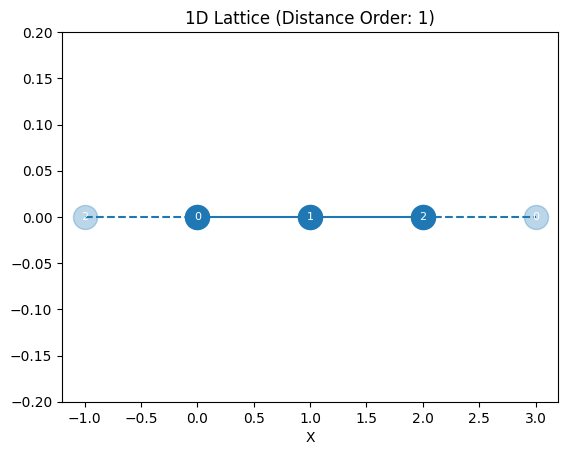

<Axes: title={'center': '1D Lattice (Distance Order: 1)'}, xlabel='X'>

In [2]:
g.draw()

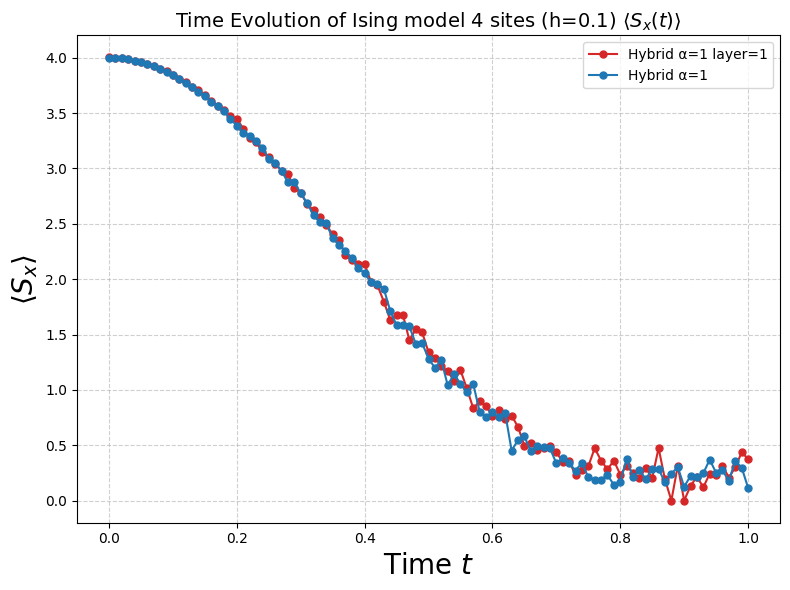

In [21]:
import json
import matplotlib.pyplot as plt

# 加载日志文件（注意：NetKet 的 JsonLog 默认是单行 JSON）
log_file = 'example_ising1d_TE.log'

with open(log_file, 'r') as f:
    data = json.load(f)  # 使用 json.load，不是 json.loads 每一行！
times = data['Sx']['iters']
s_x_real = data['Sx']['Mean']['real']
# s_x_real2 = data2['Sx']['Mean']['real']
# 如果想画复数模长，可用：np.abs(np.array(s_x_real) + 1j * np.array(data['Sx']['Mean']['imag']))

# 绘图
plt.figure(figsize=(8, 6))
plt.plot(times, s_x_real, 'o-', color='tab:red', markersize=5,label='Hybrid α=1 layer=1')
plt.plot(times, s_x_real2, 'o-', color='tab:blue', markersize=5,label='Hybrid α=1')
plt.title(r'Time Evolution of Ising model 4 sites (h=0.1) $\langle S_x(t) \rangle$', fontsize=14)
plt.xlabel('Time $t$', fontsize=20)
plt.ylabel(r'$\langle S_x \rangle$', fontsize=20)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.legend()
plt.show()

In [ ]:
import netket as nk
import numpy as np

import netket.experimental as nkx

# 1D chain
L =4

g = nk.graph.Hypercube(length=L, n_dim=1, pbc=True)

# Hilbert space of spins on the graph
hi = nk.hilbert.Spin(s=1 / 2, N=g.n_nodes, inverted_ordering=True)

# Ising spin hamiltonian
ha = nk.operator.Ising(hilbert=hi, graph=g, h=1.0)

# RBM Spin Machine
ma = nk.models.RBMModPhase(alpha=2, param_dtype=complex)

# Metropolis Local Sampling
sa = nk.sampler.MetropolisHamiltonian(hi, ha, n_chains=16)

# Variational state
vs = nk.vqs.MCState(sa, ma, n_samples=1024, n_discard_per_chain=16)

# Optimizer
op = nk.optimizer.Sgd(0.01)
sr = nk.optimizer.SR(diag_shift=1e-4)

# Variational monte carlo driver
gs = nk.driver.VMC(ha, op, variational_state=vs)

# Create observable
Sx = sum([nk.operator.spin.sigmax(hi, i) for i in range(L)])

# Run the optimization for 300 iterations to determine the ground state, used as
# initial state of the time-evolution
gs.run(n_iter=3, out="example_ising1d_GS", obs={"Sx": Sx})

# Create ODE solver for time propagation
solver = nkx.dynamics.RK23(dt=0.01, adaptive=True, rtol=1e-3, atol=1e-3)
print(solver)

# Quenched hamiltonian: this has a different transverse field than `ha`
ha1 = nk.operator.Ising(hilbert=hi, graph=g, h=0.5)
te = nkx.TDVP(
    ha1,
    variational_state=vs,
    ode_solver=solver,
    t0=0.0,
    qgt=nk.optimizer.qgt.QGTJacobianDense(holomorphic=True, diag_shift=1e-4),
    error_norm="qgt",
)

log = nk.logging.JsonLog("example_ising1d_TE_mod_3sites")

# perform the time-evolution saving the observable Sx at every `tstop` time
te.run(
    T=1.0,
    out=log,
    show_progress=True,
    obs={"Sx": Sx},
    tstops=np.linspace(0.0, 1.0, 101, endpoint=True),
)

100%|██████████| 3/3 [00:00<00:00, 23.61it/s, Energy=-4.004-0.000j ± 0.062 [σ²=3.950, R̂=1.0052]]


RKExplicitSolver(tableau=RK23, dt=0.01, adaptive=True, integrator_parameters=IntegratorParameters(dt=0.01, atol=0.001, rtol=0.001, dt_limits=(None, 0.1)))


100%|██████████| 1.00/1.00 [00:32<00:00, 32.0s/it, n=114, Generator=-2.165+0.015j ± 0.084 [σ²=4.197, R̂=1.0924]] 


(JsonLog('example_ising1d_TE_mod', mode=write, autoflush_cost=0.005)
   Runtime cost:
   	Log:    0.0482785701751709
   	Params: 0.028725147247314453,)

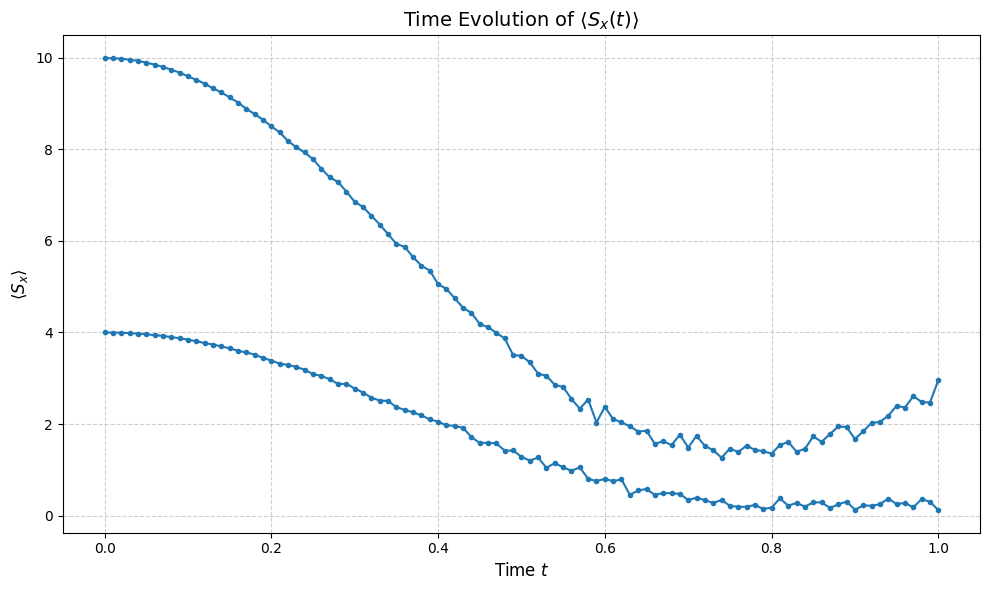

In [6]:
import json
import matplotlib.pyplot as plt

# 加载日志文件（注意：NetKet 的 JsonLog 默认是单行 JSON）
log_file = 'example_ising1d_TE.log'

with open(log_file, 'r') as f:
    data = json.load(f)  # 使用 json.load，不是 json.loads 每一行！

with open('example_ising1d_TE_mod.log', 'r') as f:
    data2 = json.load(f)  # 使用 json.load，不是 json.loads 每一行！
# 提取时间与 <Sx> 实部（虚部通常接近0，可忽略）
times = data['Sx']['iters']
s_x_real = data['Sx']['Mean']['real']
s_x_real2 = data2['Sx']['Mean']['real']
# 如果想画复数模长，可用：np.abs(np.array(s_x_real) + 1j * np.array(data['Sx']['Mean']['imag']))

# 绘图
plt.figure(figsize=(10, 6))
plt.plot(times, s_x_real, 'o-', color='tab:blue', markersize=3)
plt.plot(times, s_x_real2, 'o-', color='tab:blue', markersize=3)
plt.title(r'Time Evolution of $\langle S_x(t) \rangle$', fontsize=14)
plt.xlabel('Time $t$', fontsize=12)
plt.ylabel(r'$\langle S_x \rangle$', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()